In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
df.shape

(46000, 3)

In [4]:
df.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [5]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["amfi_code", "date"])

df.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [6]:
df["daily_return"] = (
    df.groupby("amfi_code")["nav"]
      .pct_change()
)

In [7]:
returns_df = df.dropna(subset=["daily_return"]).copy()

returns_df.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [8]:
var_95 = (
    returns_df.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
)

In [9]:
historical_var_95 = -var_95

In [10]:
def calculate_cvar(group):
    var_threshold = group["daily_return"].quantile(0.05)

    cvar = group.loc[
        group["daily_return"] <= var_threshold,
        "daily_return"
    ].mean()

    return pd.Series({
        "VaR_95": -var_threshold,
        "CVaR_95": -cvar
    })

In [11]:
risk_results = (
    returns_df.groupby("amfi_code", group_keys=False)
    .apply(calculate_cvar, include_groups=False)
    .reset_index()
)

In [12]:
risk_results = (
    returns_df.groupby("amfi_code")["daily_return"]
    .apply(lambda x: pd.Series({
        "VaR_95": -x.quantile(0.05),
        "CVaR_95": -x[x <= x.quantile(0.05)].mean()
    }))
    .unstack()
    .reset_index()
)

In [13]:
risk_results.head()

,amfi_code,VaR_95,CVaR_95
0,100016,0.014364,0.018060
1,100025,0.003793,0.004994
2,100033,0.019034,0.023456
3,101206,0.013282,0.017439
4,101207,0.026021,0.032459


In [14]:
risk_results["VaR_95_pct"] = risk_results["VaR_95"] * 100
risk_results["CVaR_95_pct"] = risk_results["CVaR_95"] * 100

risk_results.head()

,amfi_code,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
0,100016,0.014364,0.018060,1.436364,1.806021
1,100025,0.003793,0.004994,0.379325,0.499376
2,100033,0.019034,0.023456,1.903354,2.345576
3,101206,0.013282,0.017439,1.328166,1.743943
4,101207,0.026021,0.032459,2.602125,3.245906


In [15]:
risk_results = risk_results.sort_values(
    "VaR_95",
    ascending=False
)

risk_results.head(10)

,amfi_code,VaR_95,CVaR_95,VaR_95_pct,CVaR_95_pct
22,119599,0.026859,0.032384,2.685944,3.238412
17,119095,0.026188,0.031667,2.618842,3.166729
4,101207,0.026021,0.032459,2.602125,3.245906
11,118634,0.025438,0.032304,2.543811,3.230407
21,119598,0.024507,0.030595,2.450705,3.059526
39,149324,0.023483,0.031036,2.348307,3.103625
7,102886,0.019220,0.023251,1.922028,2.325086
2,100033,0.019034,0.023456,1.903354,2.345576
25,120505,0.018892,0.024342,1.889179,2.434207
16,119094,0.018480,0.024260,1.848028,2.426006


In [16]:
risk_results.to_csv(
    "../data/processed/var_cvar_results.csv",
    index=False
)

In [17]:
key_funds = returns_df["amfi_code"].unique()[:5]

key_funds

array([100016, 100025, 100033, 101206, 101207])

In [18]:
rolling_sharpe_df = returns_df.copy()

rolling_sharpe_df["rolling_90d_sharpe"] = (
    rolling_sharpe_df.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean() /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

In [19]:
rolling_sharpe_df[
    ["amfi_code", "date", "daily_return", "rolling_90d_sharpe"]
].head(100)

,amfi_code,date,daily_return,rolling_90d_sharpe
5751,100016,2022-01-04,-0.010306,NaN
5752,100016,2022-01-05,0.012865,NaN
5753,100016,2022-01-06,-0.011377,NaN
5754,100016,2022-01-07,-0.001210,NaN
5755,100016,2022-01-10,-0.008639,NaN
...,...,...,...,...
5846,100016,2022-05-17,0.026682,-0.029988
5847,100016,2022-05-18,-0.008220,-0.132298
5848,100016,2022-05-19,-0.007582,-0.194050
5849,100016,2022-05-20,-0.004461,-0.415433


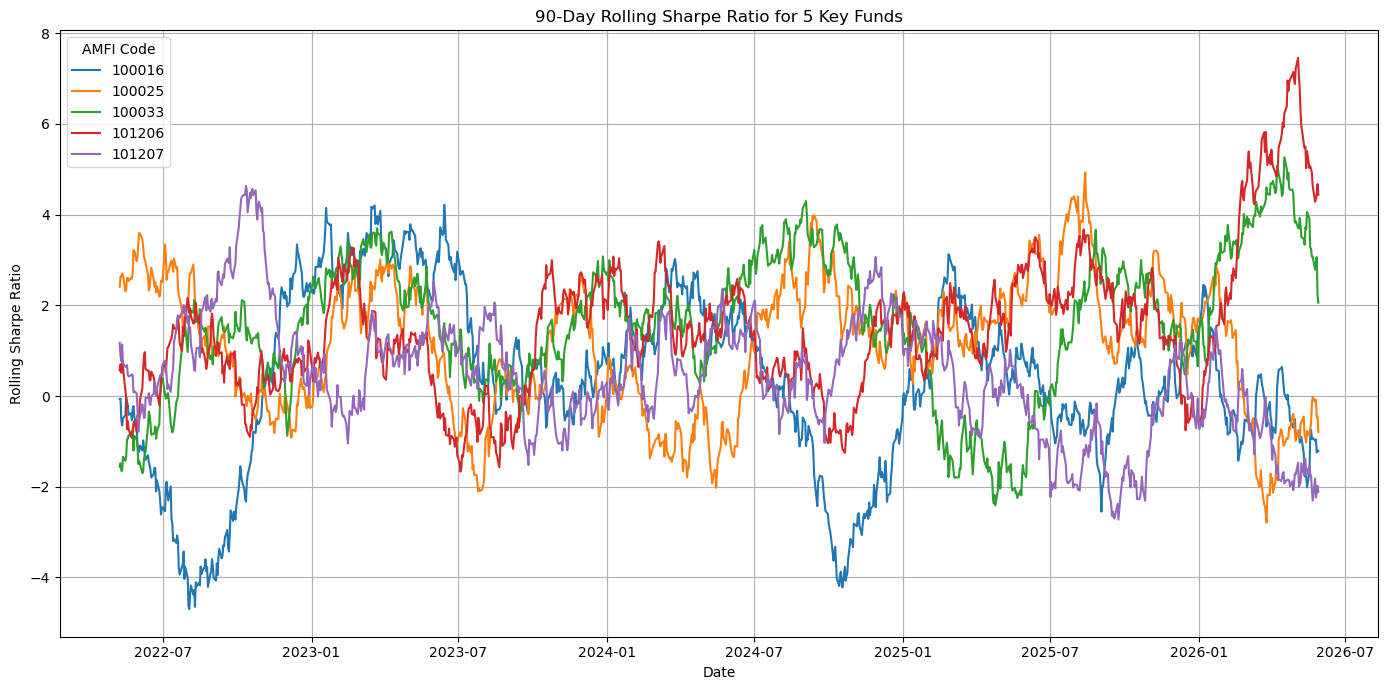

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

for fund in key_funds:
    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_90d_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio for 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_90day_sharpe.png",
    dpi=300
)

plt.show()